In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\BAJWA LAPTOPS\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


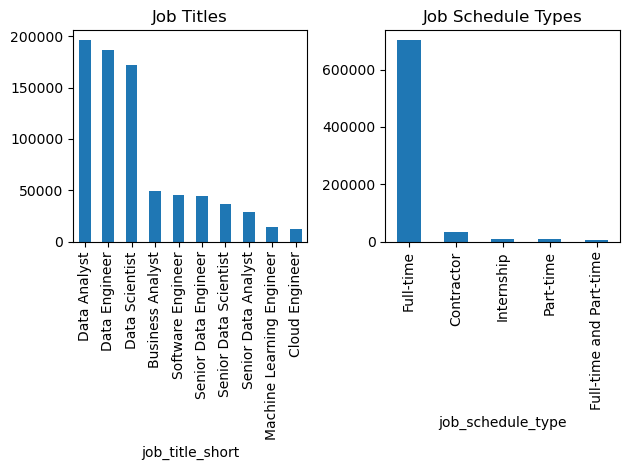

In [5]:
fig, ax = plt.subplots(1,2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])
df['job_schedule_type'].value_counts().head(5).plot(kind='bar', ax=ax[1])
ax[0].set_title("Job Titles")
ax[1].set_title("Job Schedule Types")
plt.tight_layout()

#Example Count of Top Skills in Job Postings
-----------------------------------------



In [17]:
df_skills = df.copy()

df_skills = df_skills.explode('job_skills')

skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


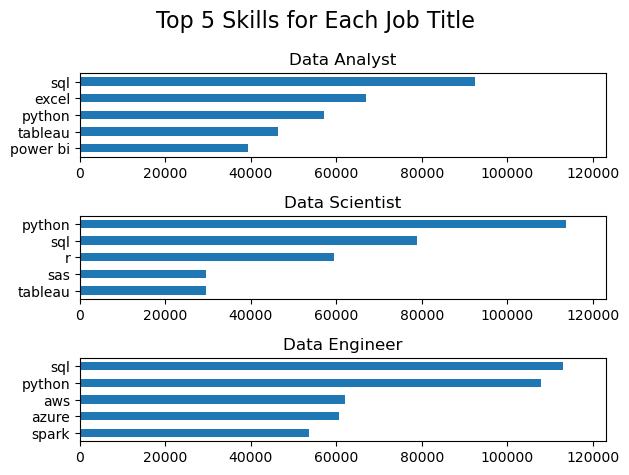

In [46]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

last= df_job['skill_count'].max()

fa, ax = plt.subplots(3,1)

for i, jobs in enumerate(job_titles):
    df_job = df_skills_count[df_skills_count['job_title_short'] == jobs].head(5)
    df_job.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], legend=False)
    ax[i].set_title(jobs)
    ax[i].invert_yaxis()
    ax[i].set_ylabel("")
    ax[i].set_xlim(0, last + 10000)

plt.suptitle("Top 5 Skills for Each Job Title", fontsize=16)
plt.tight_layout()